In [6]:
from nba_api.stats.endpoints import playergamelogs

logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season"
)

df = logs.get_data_frames()[0]

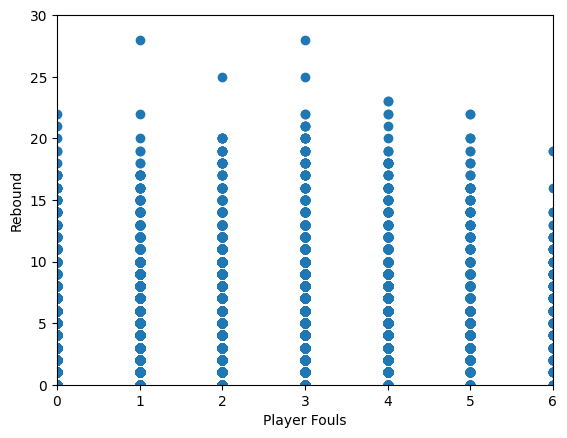

Players foul vs Rebound Correlation 0.2910726795110752
R2 0.08472330475775713


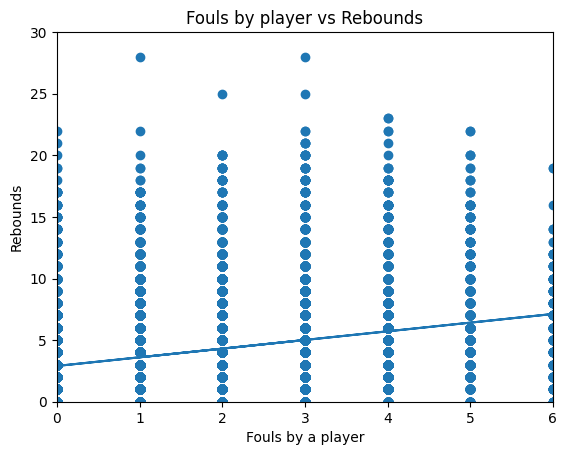

In [ ]:
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

players_fouls_reb = df[["PF","REB"]]

##print(players_fouls_reb.head())
##print(players_fouls_reb.shape)



plt.scatter(players_fouls_reb["PF"],players_fouls_reb["REB"])
plt.xlim(0, 6)
plt.ylim(0, 30)
plt.xlabel("Player Fouls")
plt.ylabel("Rebound")
plt.show()
print("Correlation", players_fouls_reb["PF"].corr(players_fouls_reb["REB"]))

X= players_fouls_reb[["PF"]]
y = players_fouls_reb["REB"]
model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)
print("R2",r2)
predictions = model.predict(X)
plt.scatter(players_fouls_reb["PF"], players_fouls_reb["REB"])

plt.plot(players_fouls_reb["PF"], predictions)

plt.xlim(0, 6)
plt.ylim(0, 30)

plt.xlabel("Fouls by a player")
plt.ylabel("Rebounds")
plt.title("Fouls by player vs Rebounds")

plt.show()




<Figure size 800x500 with 0 Axes>

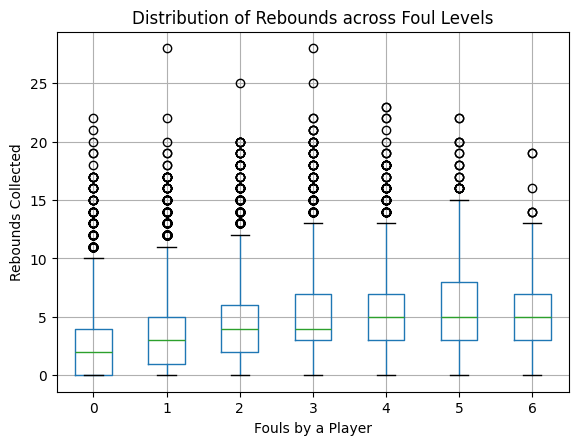

In [12]:
plt.figure(figsize=(8, 5))

# Use the built-in pandas boxplot engine grouped by your player fouls column
# 'column' is your target Y-axis, 'by' splits the data into the 0-6 columns on the X-axis
players_fouls_reb.boxplot(column="REB", by="PF")

# Clean up formatting titles and display
plt.title("Distribution of Rebounds across Foul Levels")
plt.suptitle("") # Clears out the default automatic pandas title layout
plt.xlabel("Fouls by a Player")
plt.ylabel("Rebounds Collected")
plt.show()

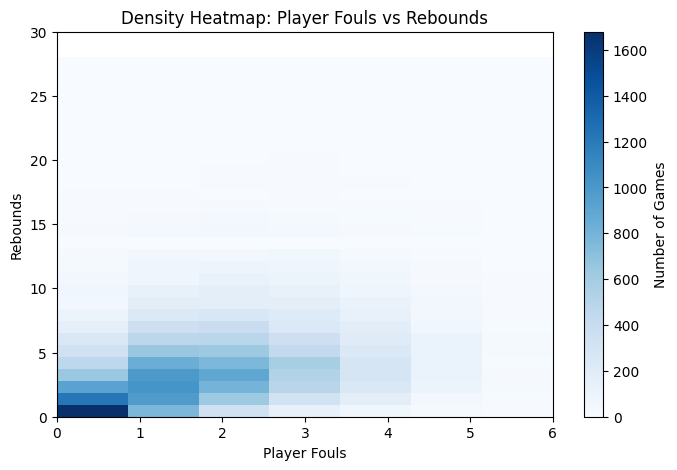

In [13]:
# Set up your canvas size
plt.figure(figsize=(8, 5))

# Generate a 2D density heatmap
# bins=[7, 30] tells it to split the X-axis into 7 foul blocks and Y-axis into 30 rebound blocks
# cmap="Blues" sets the color gradient (darker blue = more games)
plt.hist2d(players_fouls_reb["PF"], players_fouls_reb["REB"], bins=[7, 30], cmap="Blues")

# Add a color bar legend to the side showing game counts
plt.colorbar(label="Number of Games")

# Align your axis scales to match your scatter plots
plt.xlim(0, 6)
plt.ylim(0, 30)

plt.xlabel("Player Fouls")
plt.ylabel("Rebounds")
plt.title("Density Heatmap: Player Fouls vs Rebounds")
plt.show()


In [ ]:
"""Feature: PF (Personal Fouls Committed)

Relationship: 
Weak-to-moderate positive relationship with REB (Counter-intuitive).

Correlation: 
~0.291

R²: 
~0.085

Why it matters / The Basketball Logic: 
A classic statistical confound. Interior big men who play closest to the 
rim contract the most physical contact, naturally driving up BOTH their 
rebound totals and personal foul counts simultaneously. Raw same-game 
fouls tell us about interior positioning, not negative impact.

Pregame usable? 
No, actual game-night foul trouble is unknown before tip-off.

Possible transformation (CRITICAL FOR FUTURE FEATURE ENGINEERING STEP): 
FOUL_RATE_PER_MIN_L10 = (PF_LAST_10 / MIN_LAST_10)

Potential future use: 
Yes, but do NOT use raw fouls. Carry forward the historical rolling 
foul rate proxy. This allows the machine learning model to flag players 
at high risk for early coaching benches (e.g., getting in quick first-half 
foul trouble), automatically capping their expected minutes and rebounding 
projections against aggressive interior opponents."""""


""" AI NOTE: The Transformation: Calculate a historical rolling feature named FOUL_RATE_PER_MIN over a player's last 10 games 
(Fouls / Minutes).How the Model Uses It: If a player has a high baseline foul rate and faces an 
opponent team that draws a massive volume of paint fouls, your future machine learning model can automatically
 learn to downgrade their expected minutes—and subsequent rebounding projections—for that night's matchup."""